# Random Forest


1. Загружается датасет Wine
2. Обучается ансамбль Random Forest
3. Подбираются оптимальные гиперпараметры через Grid Search (по OOB)
4. Вычисляется важность признаков через OOB^j
5. Проводится сравнение с эталонной реализацией sklearn

In [1]:
import numpy as np
import time
import sys
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestClassifier as SklearnRF
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from source.random_forest import CustomRandomForestClassifier

## Загрузка датасета Wine

Wine — классический датасет для классификации: 13 признаков (химический состав вина), 3 класса сортов винограда.

In [2]:
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} объектов, {X_train.shape[1]} признаков")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")
print(f"Классы: {target_names}")

Обучающая выборка: 124 объектов, 13 признаков
Тестовая выборка: 54 объектов
Классы: ['class_0' 'class_1' 'class_2']


## Grid Search по OOB для подбора гиперпараметров

Подбор оптимальных параметров по OOB-оценке (не требуется отдельная валидационная выборка).
Глубокие деревья более вариативны, легко переобучаются.
Если max_depth маленький, каждое дерево слабее, вариативность меньше.
Сложность ансамбля обпределяется не количеством базовых алгоритмов, а сложностью базового алгоритма в отдельности. Так или иначе требуется баланс между количеством деревьев и их глубиной.

In [3]:
param_grid = {
    'n_estimators': [50, 100, 150], # Количество деревьев
    'max_features': ['sqrt', 'log2', 0.5], # Макс. признаков при разбиении √(n_features) log2(n_features)
    'max_depth': [5, 10, 15, None], # Максимальная глубина деревьев
    'min_samples_split': [2, 5], # Минимум сэмплов для разбиения
    'random_state': [42]
}

results = []
for params in ParameterGrid(param_grid):
    model = CustomRandomForestClassifier(**params)
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    t1 = time.perf_counter()
    results.append({
        **params,
        'oob_score': model.oob_score_,
        'time': t1 - t0
    })

results_sorted = sorted(results, key=lambda x: x['oob_score'], reverse=True)
best_params = {k: v for k, v in results_sorted[0].items() if k != 'oob_score' and k != 'time'}
print(f"\nЛучшие параметры (по OOB): {best_params}")
print(f"OOB Score: {results_sorted[0]['oob_score']:.4f}")


Лучшие параметры (по OOB): {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100, 'random_state': 42}
OOB Score: 0.9839


## Обучение финальной модели с оптимальными параметрами

In [4]:
model_custom = CustomRandomForestClassifier(**best_params)
t0 = time.perf_counter()
model_custom.fit(X_train, y_train)
time_custom_fit = time.perf_counter() - t0

acc_custom = accuracy_score(y_test, model_custom.predict(X_test))
print(f"Точность на тесте (наша реализация): {acc_custom:.4f}")
print(f"OOB Score: {model_custom.oob_score_:.4f}")
print(f"Время обучения: {time_custom_fit:.3f} с")

Точность на тесте (наша реализация): 0.9815
OOB Score: 0.9839
Время обучения: 0.108 с


## Важность признаков через OOB^j

OOB^j — оценка важности признака j через пермутацию в OOB-выборке: замена значений признака j случайной перестановкой и измерение падения OOB-точности.

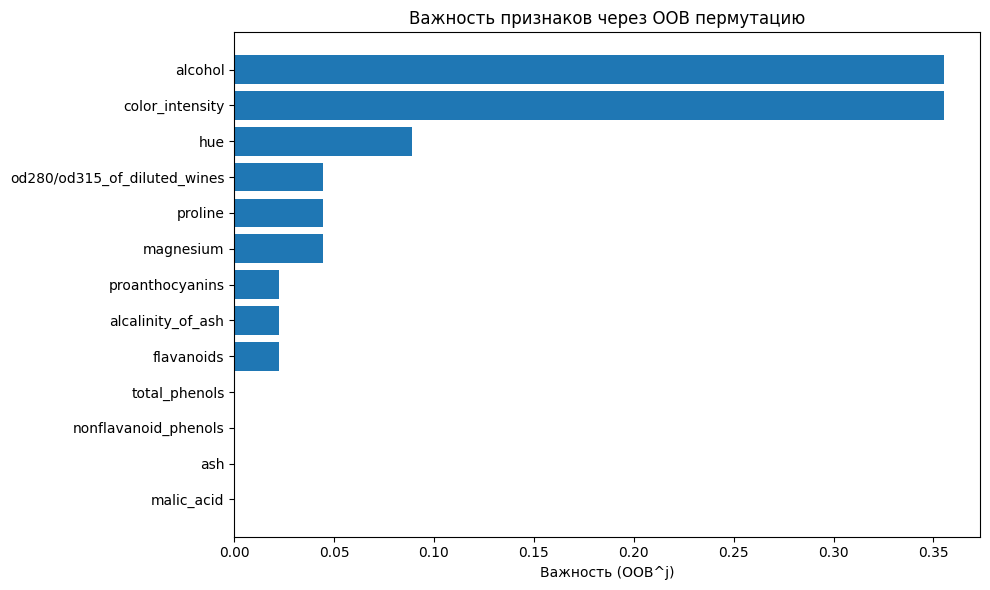


Признаки по убыванию важности:
  alcohol: 0.3556
  color_intensity: 0.3556
  hue: 0.0889
  od280/od315_of_diluted_wines: 0.0444
  proline: 0.0444
  magnesium: 0.0444
  proanthocyanins: 0.0222
  alcalinity_of_ash: 0.0222
  flavanoids: 0.0222
  total_phenols: 0.0000
  nonflavanoid_phenols: 0.0000
  ash: 0.0000
  malic_acid: 0.0000


In [7]:
importances_oob = model_custom.get_feature_importances_oob(
    X_train, y_train, n_repeats=3, random_state=42
)

indices = np.argsort(importances_oob)[::-1]
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_names)), importances_oob[indices])
plt.yticks(range(len(feature_names)), [feature_names[i] for i in indices])
plt.xlabel('Важность (OOB^j)')
plt.title('Важность признаков через OOB пермутацию')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nПризнаки по убыванию важности:")
for i in indices:
    print(f"  {feature_names[i]}: {importances_oob[i]:.4f}")

## Сравнение с эталонной реализацией sklearn

Сравнение: точность модели и время обучения.

In [8]:
params_sklearn = {k: v for k, v in best_params.items() if k in ['n_estimators', 'max_features', 'max_depth', 'min_samples_split', 'random_state']}
model_sklearn = SklearnRF(oob_score=True, **params_sklearn)

t0 = time.perf_counter()
model_sklearn.fit(X_train, y_train)
time_sklearn_fit = time.perf_counter() - t0

acc_sklearn = accuracy_score(y_test, model_sklearn.predict(X_test))

print("=" * 60)
print("Сравнение: наша реализация vs sklearn")
print("=" * 60)
print(f"{'Метрика':<25} {'Наша реализация':<20} {'sklearn':<20}")
print("-" * 60)
print(f"{'Точность на тесте':<25} {acc_custom:<20.4f} {acc_sklearn:<20.4f}")
print(f"{'OOB Score':<25} {model_custom.oob_score_:<20.4f} {model_sklearn.oob_score_:<20.4f}")
print(f"{'Время обучения (с)':<25} {time_custom_fit:<20.3f} {time_sklearn_fit:<20.3f}")
print("=" * 60)

Сравнение: наша реализация vs sklearn
Метрика                   Наша реализация      sklearn             
------------------------------------------------------------
Точность на тесте         0.9815               1.0000              
OOB Score                 0.9839               0.9758              
Время обучения (с)        0.108                0.128               
